# In-depth Analysis of Ookla Performance Data in Albay, Philippines
This notebook demonstrates how to load locally downloaded fixed broadband performance data for Albay.
It uses precise Admin 3 (Municipality/City) boundaries to calculate localized baseline latencies, 
overall provincial baseline latency, and creates a choropleth map.

In [1]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
import pandas as pd
import numpy as np

## 1. Fetch Boundaries
We will use the `albay_admin3.geojson` dataset to precisely join tiles to their respective municipalities.

In [2]:
print("Loading Admin 3 (Municipality) boundaries for Albay...")
albay = gpd.read_file("albay_admin3.geojson").to_crs(4326)

Loading Admin 3 (Municipality) boundaries for Albay...


## 2. Load Local Ookla Data
We load the data from our pre-downloaded local parquet file. 
(Run `download_ookla_data.py` first if this file is missing).

In [3]:
service = "fixed"
year = 2024
quarter = 4
local_file = f"albay_ookla_{service}_{year}_q{quarter}.parquet"

print(f"Loading {service} network data for Q{quarter} {year} from local file '{local_file}'...")
try:
    tiles_df = pd.read_parquet(local_file)
    print(f"Successfully loaded {len(tiles_df)} tiles.")
except FileNotFoundError:
    print(f"Error: '{local_file}' not found. Please run 'download_ookla_data.py' first.")
    raise

Loading fixed network data for Q4 2024 from local file 'albay_ookla_fixed_2024_q4.parquet'...
Successfully loaded 2177 tiles.


## 3. Spatial Join
We convert the DataFrame to a GeoDataFrame and perform an inner spatial join with the Albay municipalities.
This assigns each Ookla data tile to a specific municipality (`adm3_name`).

In [4]:
tiles_gdf = gpd.GeoDataFrame(
    tiles_df, 
    geometry=gpd.points_from_xy(tiles_df.tile_x, tiles_df.tile_y), 
    crs="EPSG:4326"
)

print("Performing strict spatial join...")
albay_tiles = gpd.sjoin(tiles_gdf, albay, how="inner", predicate="intersects")

# Convert speeds from kbps to Mbps for easier reading
albay_tiles['avg_d_mbps'] = albay_tiles['avg_d_kbps'] / 1000
albay_tiles['avg_u_mbps'] = albay_tiles['avg_u_kbps'] / 1000
print(f"Found {len(albay_tiles)} tiles strictly inside Albay.")

Performing strict spatial join...
Found 1338 tiles strictly inside Albay.


## 4. Overall Province Baseline Latency
We calculate the weighted average baseline latency for the entire province.

In [5]:
overall_lat = np.average(albay_tiles['avg_lat_ms'], weights=albay_tiles['tests'])
overall_dl = np.average(albay_tiles['avg_d_mbps'], weights=albay_tiles['tests'])
overall_ul = np.average(albay_tiles['avg_u_mbps'], weights=albay_tiles['tests'])

print("=====================================================")
print(f" ENTIRE ALBAY REGION - OVERALL BASELINE LATENCY: {overall_lat:.2f} ms")
print("=====================================================")
print(f" (Overall Average Download: {overall_dl:.2f} Mbps)")
print(f" (Overall Average Upload: {overall_ul:.2f} Mbps)")
print("=====================================================\n")

 ENTIRE ALBAY REGION - OVERALL BASELINE LATENCY: 24.09 ms
 (Overall Average Download: 105.58 Mbps)
 (Overall Average Upload: 102.40 Mbps)



## 5. Summary Statistics (Per Municipality)
Now we group the tiles by municipality and calculate the weighted average baseline latency.

In [6]:
def weighted_avg(x):
    # If there are no tests, return NaNs
    if x['tests'].sum() == 0:
        return pd.Series({'avg_lat_ms': np.nan, 'avg_d_mbps': np.nan, 'avg_u_mbps': np.nan, 'total_tests': 0})
    
    return pd.Series({
        'avg_lat_ms': np.average(x['avg_lat_ms'], weights=x['tests']),
        'avg_d_mbps': np.average(x['avg_d_mbps'], weights=x['tests']),
        'avg_u_mbps': np.average(x['avg_u_mbps'], weights=x['tests']),
        'total_tests': x['tests'].sum()
    })

muni_stats = albay_tiles.groupby('adm3_name').apply(weighted_avg).reset_index()

# Sort by lowest latency (which is best)
muni_stats = muni_stats.sort_values(by='avg_lat_ms', ascending=True).round(2)

print("--- MUNICIPALITY PERFORMANCE RANKING (Lowest to Highest Latency) ---")
try:
    display(muni_stats) # Works in Jupyter Notebook
except NameError:
    print(muni_stats.to_string()) # Fallback for standard Python script

--- MUNICIPALITY PERFORMANCE RANKING (Lowest to Highest Latency) ---


,adm3_name,avg_lat_ms,avg_d_mbps,avg_u_mbps,total_tests
16,Santo Domingo (Libog),14.48,113.20,113.00,605.0
2,City of Ligao,14.89,113.36,112.85,1859.0
17,Tiwi,15.42,105.73,104.35,784.0
6,Jovellar,16.35,41.07,43.67,205.0
13,Pio Duran,19.48,71.45,88.62,247.0
9,Malilipot,20.03,102.42,99.04,756.0
10,Malinao,22.00,98.68,100.28,532.0
4,Daraga (Locsin),22.45,119.89,113.76,5246.0
3,City of Tabaco,22.91,113.86,112.12,2722.0
1,Camalig,23.72,97.19,96.81,1245.0


## 6. Geospatial Visualization (Choropleth Map for Baseline Latency)
Let's merge these statistics back into the municipality polygons so we can plot a latency choropleth map.


Visualization saved to 'albay_muni_latency_map.png'


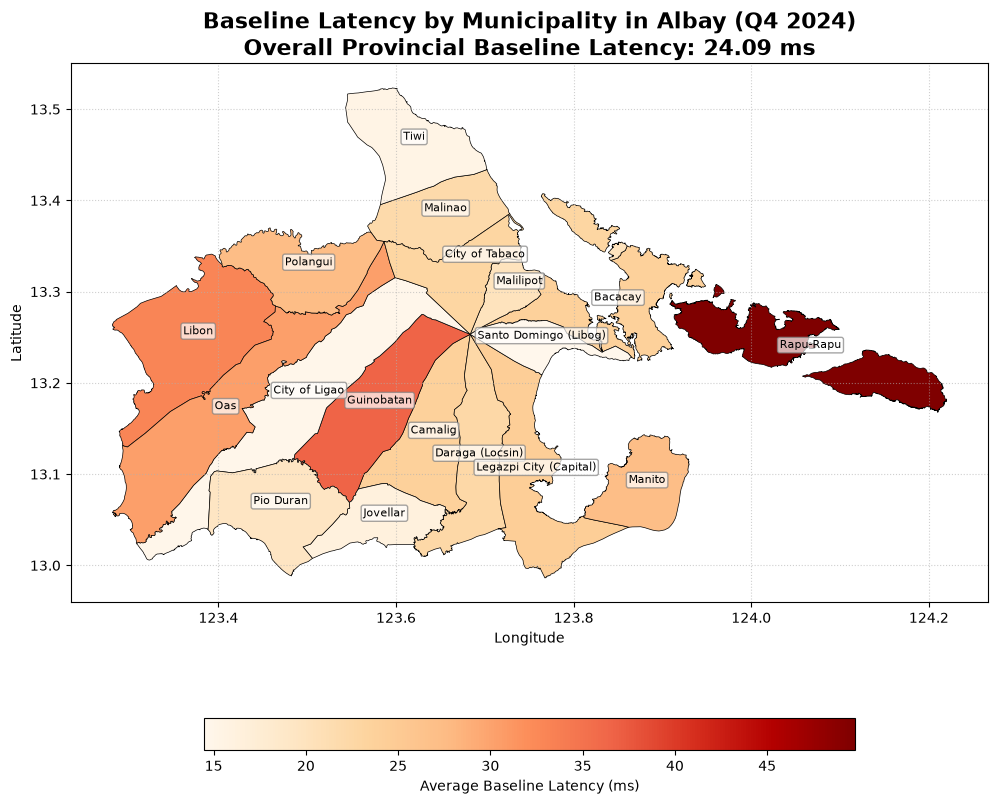

In [7]:
# Merge stats with polygons
albay_muni_gdf = albay[['adm3_name', 'geometry']].merge(muni_stats, on='adm3_name')

fig, ax = plt.subplots(figsize=(14, 10))

# Plot the choropleth map for Baseline Latency
# We use 'OrRd' (Orange-Red) where darker red indicates higher (worse) latency
albay_muni_gdf.plot(
    column='avg_lat_ms', 
    ax=ax, 
    cmap='OrRd', 
    edgecolor='black',
    linewidth=0.5,
    legend=True,
    legend_kwds={'label': 'Average Baseline Latency (ms)', 'orientation': 'horizontal', 'shrink': 0.6}
)

# Label the municipalities
for idx, row in albay_muni_gdf.iterrows():
    # Only label if we have a valid geometry centroid
    if not row['geometry'].is_empty:
        centroid = row['geometry'].centroid
        ax.annotate(text=row['adm3_name'], xy=(centroid.x, centroid.y), 
                    xytext=(3, 3), textcoords="offset points", 
                    fontsize=8, ha='center', color='black',
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.7))

# Add the Overall Latency to the Title
ax.set_title(f'Baseline Latency by Municipality in Albay (Q4 2024)\nOverall Provincial Baseline Latency: {overall_lat:.2f} ms', fontsize=16, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig('albay_muni_latency_map.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved to 'albay_muni_latency_map.png'")